In [1]:
from sklearn.datasets import load_breast_cancer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

### Actividad 1

In [2]:
datos = load_breast_cancer(as_frame=True)
X = datos.data
y = datos.target

print(f"Total de Observaciones: {X.shape[0]} | Variables: {X.shape[1]}")
print("=" * 50)
print(f"Valores faltantes:\n{X.isna().sum()}")
print("=" * 50)
print(f"Variables: {dict(enumerate(datos.target_names))}")

Total de Observaciones: 569 | Variables: 30
Valores faltantes:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Variables: {0: np.str_('malignant'), 1: np.str_('benig

### Actividad 2

           casos  porcentaje
malignant    212      37.258
benign       357      62.742
Exactitud de un modelo que responde siempre benign - 62.742


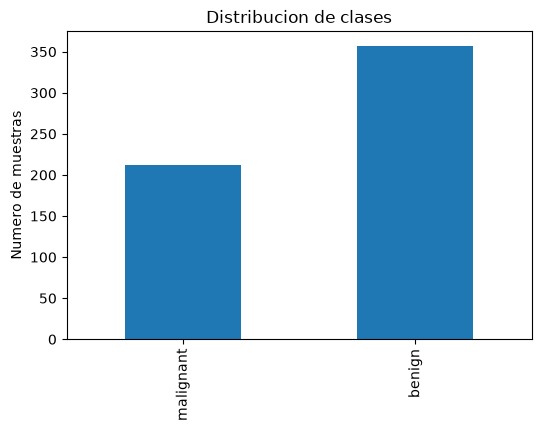

In [3]:
conteo = y.value_counts().sort_index()
conteo.index = datos.target_names

porcentaje = ((conteo / conteo.sum()) * 100).round(3)
resumen = pd.DataFrame({"casos": conteo, "porcentaje": porcentaje})
print(resumen)

mayoritaria = conteo.max() / conteo.sum() * 100
print(f"Exactitud de un modelo que responde siempre {conteo.idxmax()} - {mayoritaria:.3f}")

conteo.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Numero de muestras")
plt.title("Distribucion de clases")
plt.show()

### Actividad 3

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

_, _, sin_y_train, sin_y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

comparador = pd.DataFrame({
    "conjunto completo": y.value_counts(normalize=True).sort_index(),
    "train (stratificado)": y_train.value_counts(normalize=True).sort_index(),
    "train (sin stratificado)": sin_y_train.value_counts(normalize=True).sort_index(),
    "test (stratificado)": y_test.value_counts(normalize=True).sort_index(),
    "test (sin stratificado)": sin_y_test.value_counts(normalize=True).sort_index()
})

comparador.index = datos.target_names
comparador.head(5)

,conjunto completo,train (stratificado),train (sin stratificado),test (stratificado),test (sin stratificado)
malignant,0.372583,0.373626,0.371429,0.368421,0.377193
benign,0.627417,0.626374,0.628571,0.631579,0.622807


### Actividad 4

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


trivial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
trivial.fit(X_train, y_train)

pred_trivial = trivial.predict(X_test)

print(f"Exactitud: {accuracy_score(y_test, pred_trivial):.5f}")
print(f"Recall sobre la clase benigna (clase 1): {recall_score(y_test, pred_trivial, pos_label=1):.3f}")
print(f"Recall sobre la clase maligna (clase 0): {recall_score(y_test, pred_trivial, pos_label=0):.3f}")

Exactitud: 0.63158
Recall sobre la clase benigna (clase 1): 1.000
Recall sobre la clase maligna (clase 0): 0.000


In [6]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def evaluar(modelo, nombre, X_test, y_test):
    preds = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "exactitud": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    }

resultados = [evaluar(trivial, "Trivial", X_test, y_test)]
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.0,0.774194,0.5


### Actividad 5

In [7]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo.fit(X_train, y_train)
metricas_escalando = evaluar(modelo, "logistic regresor con escalamiento", X_test, y_test)


In [8]:
modelo_sin_escalar = Pipeline([
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_sin_escalar.fit(X_train, y_train)
metricas_sin_escalar = evaluar(modelo_sin_escalar, "logistic regresor sin escalar", X_test, y_test)

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
print(f"Exactitud con escalamiento: {metricas_escalando["exactitud"]:.3f}")
print(f"Exactitud sin escalamiento: {metricas_sin_escalar["exactitud"]:.3f}")

print(f"Iteraciones usando escalamiento: {modelo['clf'].n_iter_}")
print(f"Iteraciones sin escalamiento: {modelo_sin_escalar['clf'].n_iter_}")

Exactitud con escalamiento: 0.982
Exactitud sin escalamiento: 0.956
Iteraciones usando escalamiento: [19]
Iteraciones sin escalamiento: [1000]


### Actividad 6

In [10]:
resultados.append(
    evaluar(modelo, "Logistico", X_test, y_test)
)

comparativa = pd.DataFrame(resultados).set_index("modelo")
comparativa["recall_maligna"] = [
    recall_score(y_test, trivial.predict(X_test), pos_label=0),
    recall_score(y_test, modelo.predict(X_test), pos_label=0),
]

mejora_extactidud = comparativa.loc["Logistico", "exactitud"] - comparativa.loc["Trivial", "exactitud"]
mejora_recall = comparativa.loc["Logistico", "recall_maligna"] - comparativa.loc["Trivial", "recall_maligna"]

print(f"Mejora de exactitud: {mejora_extactidud:+.3f}")
print(f"Mejora de recall sobre casos malignos: {mejora_recall:+.3f}")

Mejora de exactitud: +0.351
Mejora de recall sobre casos malignos: +0.976


In [11]:
comparativa

,exactitud,precision,recall,f1,auc,recall_maligna
modelo,,,,,,
Trivial,0.631579,0.631579,1.000000,0.774194,0.50000,0.00000
Logistico,0.982456,0.986111,0.986111,0.986111,0.99537,0.97619


### Actividad 7

Casos con probabilidad entre 0.4 y 0.6: 3
Casos con probabiliades por debajo de 0.05: 36
Casos con probabiliades por encima de 0.95: 54


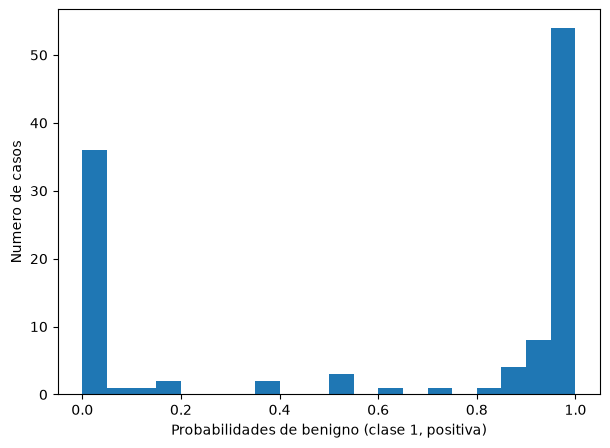

In [12]:
probabilidades = modelo.predict_proba(X_test)[:, 1]
print(
    f"Casos con probabilidad entre 0.4 y 0.6: {((probabilidades > 0.4) & (probabilidades < 0.6)).sum()}"
)
print(
    f"Casos con probabiliades por debajo de 0.05: {(probabilidades < 0.05).sum()}"
)
print(
    f"Casos con probabiliades por encima de 0.95: {(probabilidades > 0.95).sum()}"
)

plt.figure(figsize=(7,5))
plt.hist(probabilidades, bins=20)
plt.xlabel("Probabilidades de benigno (clase 1, positiva)")
plt.ylabel("Numero de casos")
plt.show()

### Actividad 8

In [13]:
probabilidades.shape

(114,)

In [14]:
probabilidades

array([5.88824186e-08, 9.99988665e-01, 6.41082462e-03, 5.33508537e-01,
       6.52500097e-10, 9.92160398e-01, 9.99982825e-01, 5.63527494e-07,
       5.43163692e-05, 8.04184941e-11, 9.89178556e-01, 1.33241870e-03,
       9.98703777e-01, 2.60592467e-05, 2.76224627e-04, 9.01632354e-01,
       3.65861856e-01, 8.34997650e-01, 9.99966119e-01, 9.83017335e-01,
       1.65771925e-03, 5.17399797e-02, 9.99807885e-01, 9.99123324e-01,
       9.90010217e-01, 8.67468162e-01, 4.83595669e-09, 9.90463784e-01,
       9.99169881e-01, 9.98922169e-01, 9.91912973e-01, 9.99989143e-01,
       9.83527366e-01, 9.69239080e-01, 5.37502995e-06, 1.87989311e-01,
       9.98451407e-01, 9.71053325e-01, 6.21262609e-01, 5.44264495e-06,
       9.99944641e-01, 9.99846730e-01, 9.93536689e-01, 2.63830968e-08,
       1.71221909e-03, 7.07218502e-01, 9.99998944e-01, 9.99818581e-01,
       9.30910616e-01, 2.69142775e-04, 9.99617017e-01, 5.46638504e-01,
       9.99381052e-01, 9.08728148e-01, 9.33799774e-01, 9.99328224e-01,
      

In [15]:
(probabilidades >= 0.5).astype(int)

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [16]:
decision_manual = (probabilidades >= 0.5).astype(int)
decision_sklearn = modelo.predict(X_test)

print(f"Coincide en todos los casos: {(decision_manual == decision_sklearn).all()}")
print(f"Casos en los que difiere: {(decision_manual != decision_sklearn).sum()}")

Coincide en todos los casos: True
Casos en los que difiere: 0


### Actividad 9

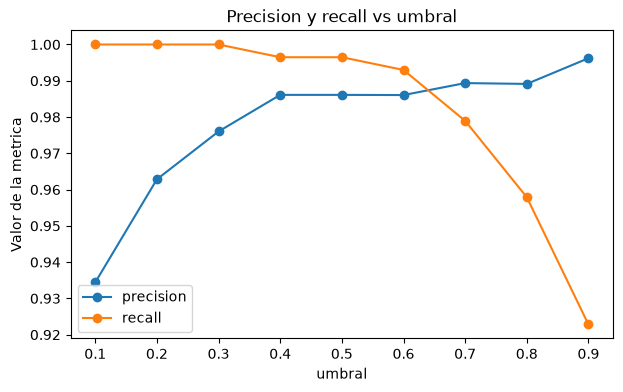

In [17]:
prob_train = modelo.predict_proba(X_train)[:, 1]

filas = []

for umbral in np.arange(0.1, 1.0, 0.1):
    pred_u = (prob_train >= umbral).astype(int)
    filas.append(
        {
            "umbral": round(umbral, 1),
            "marcados_positivos": int(pred_u.sum()),
            "precision": precision_score(y_train, pred_u),
            "recall": recall_score(y_train, pred_u),
            "f1": f1_score(y_train, pred_u)
        }
    )

tabla_umbrales = pd.DataFrame(filas).set_index("umbral")

tabla_umbrales[["precision", "recall"]].plot(figsize=(7, 4), marker="o")
plt.xlabel("umbral")
plt.ylabel("Valor de la metrica")
plt.title("Precision y recall vs umbral")
plt.show()

In [18]:
tabla_umbrales

,marcados_positivos,precision,recall,f1
umbral,,,,
0.1,305,0.934426,1.000000,0.966102
0.2,296,0.962838,1.000000,0.981067
0.3,292,0.976027,1.000000,0.987868
0.4,288,0.986111,0.996491,0.991274
0.5,288,0.986111,0.996491,0.991274
0.6,287,0.986063,0.992982,0.989510
0.7,282,0.989362,0.978947,0.984127
0.8,276,0.989130,0.957895,0.973262
0.9,264,0.996212,0.922807,0.958106


### Actividad 10

Tomando la clase benigna como positiva: VP=71 FP=1 FN=1 VN=41
Casos malignos clasificados como benignos: 1
Caso benigno clasificado como maligno: 1


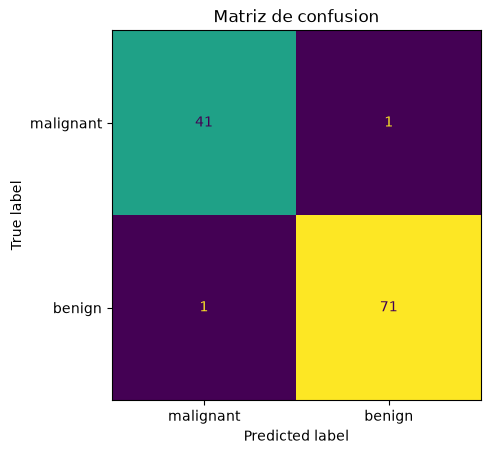

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = modelo.predict(X_test)
matriz = confusion_matrix(y_test, preds)

vn, fp, fn, vp = matriz.ravel()
print(f"Tomando la clase benigna como positiva: VP={vp} FP={fp} FN={fn} VN={vn}")
print(f"Casos malignos clasificados como benignos: {fp}")
print(f"Caso benigno clasificado como maligno: {fn}")

ConfusionMatrixDisplay.from_estimator(
    modelo, X_test, y_test, display_labels=datos.target_names, colorbar=False
)
plt.title("Matriz de confusion")
plt.show()

### Actividad 11

In [20]:
from sklearn.metrics import classification_report

preds = modelo.predict(X_test)

print(classification_report(y_test, preds, target_names=datos.target_names, digits=4))

              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### Actividad 12

### Actividad 13

### Actividad 14

### Actividad 15

### Actividad 16

### Actividad 17

### Actividad 18

### Actividad 19

### Actividad 20

### Actividad 21

### Actividad 22

### Actividad 23

### Actividad 24

### Actividad 25

### Actividad 26

### Actividad 27

### Actividad 28

### Actividad 29

### Actividad 30

### Actividad 31

### Actividad 32

### Actividad 33

### Actividad 34